# Baseline

In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

Read dataset files

In [103]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [104]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            300000 non-null  int64  
 1   Hospital                           300000 non-null  int64  
 2   Hospital_type                      300000 non-null  int64  
 3   Hospital_city                      300000 non-null  int64  
 4   Hospital_region                    300000 non-null  int64  
 5   Available_Extra_Rooms_in_Hospital  300000 non-null  int64  
 6   Department                         300000 non-null  object 
 7   Ward_Type                          300000 non-null  object 
 8   Ward_Facility                      300000 non-null  object 
 9   Bed_Grade                          299897 non-null  float64
 10  patientid                          300000 non-null  int64  
 11  City_Code_Patient                  2957

In [105]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            300000 non-null  int64  
 1   Hospital                           300000 non-null  int64  
 2   Hospital_type                      300000 non-null  int64  
 3   Hospital_city                      300000 non-null  int64  
 4   Hospital_region                    300000 non-null  int64  
 5   Available_Extra_Rooms_in_Hospital  300000 non-null  int64  
 6   Department                         300000 non-null  object 
 7   Ward_Type                          300000 non-null  object 
 8   Ward_Facility                      300000 non-null  object 
 9   Bed_Grade                          299897 non-null  float64
 10  patientid                          300000 non-null  int64  
 11  City_Code_Patient                  2957

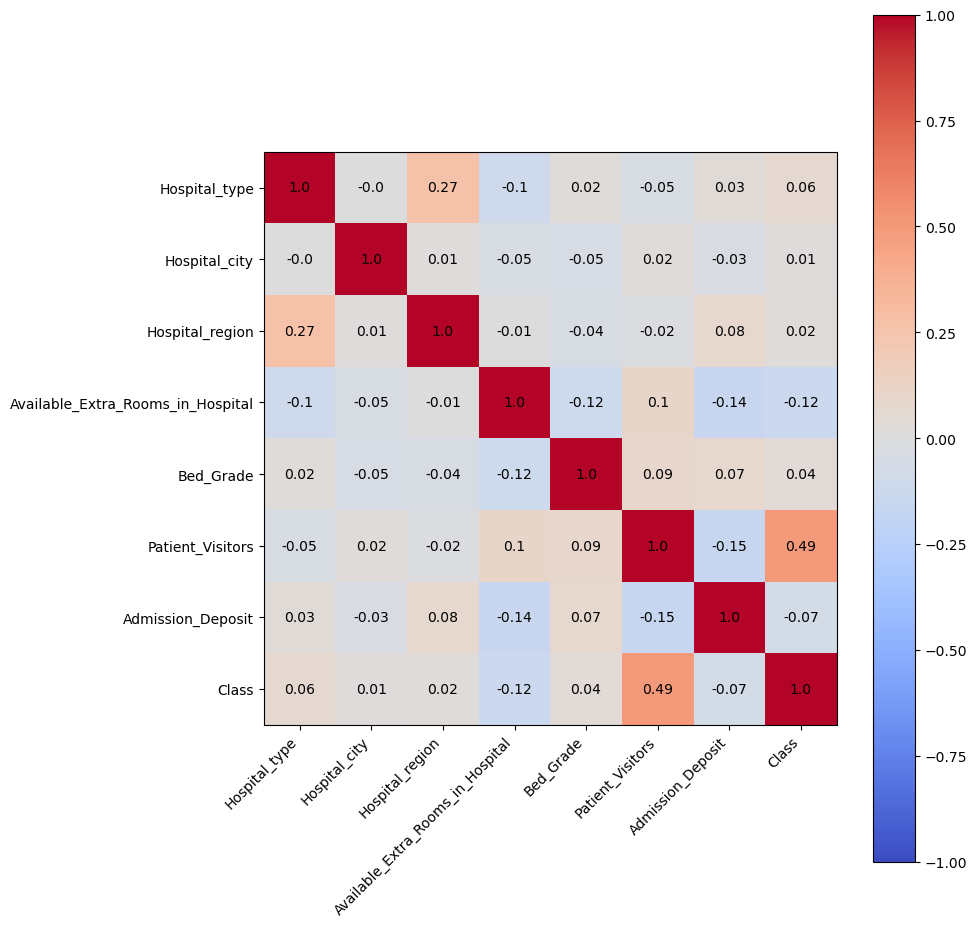

In [112]:
import matplotlib.pyplot as plt

df_corr = train_df.corr()
plt.figure(figsize=(10, 10))

plt.imshow(df_corr, cmap='coolwarm', vmin=-1, vmax=1)

plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=45, ha='right')
plt.yticks(range(len(df_corr.columns)), df_corr.columns)

for i in range(len(df_corr.columns)) :
    for j in range(len(df_corr.columns)) :
        text = round(df_corr.iloc[i,j],2)
        plt.annotate(text, xy=(j,i), ha='center', va='center')

plt.colorbar()
plt.tight_layout()
plt.show()

Make dataset

In [107]:
train_df = train_df.drop(columns=['case_id', 'Hospital', 'patientid', 'City_Code_Patient'])
train_df = train_df.dropna()
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_test = test_df.drop(columns=['case_id', 'Hospital', 'patientid', 'City_Code_Patient'])

In [108]:
X = pd.concat([X_train, X_test], axis=0)
X = pd.get_dummies(X)

X_train = X.iloc[:len(X_train)]
X_test = X.iloc[len(X_train):]

Make model & train

In [109]:
model = LogisticRegression(penalty='l1', solver='liblinear') # L1 사용
model.fit(X_train, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

Make test prediction

In [110]:
test_pred = model.predict(X_test)

Export prediction to file

In [111]:
submission_df = pd.read_csv('sample_submission.csv')
submission_df.Class = test_pred
submission_df.to_csv('submission.csv', index=False)